### Renders 3D density plots of subhalos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize, LogNorm
import h5py
import time
import os
import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const
import raytrace

In [2]:
with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    halo_ids = list(f.keys())
list(enumerate(halo_ids))

[(0, 'halo_11069985'),
 (1, 'halo_12925051'),
 (2, 'halo_15386300'),
 (3, 'halo_18373384'),
 (4, 'halo_2069291'),
 (5, 'halo_252455'),
 (6, 'halo_4152102'),
 (7, 'halo_4356618'),
 (8, 'halo_5160064')]

In [3]:
halo_id = halo_ids[8][5:]
halo_id

'5160064'

In [4]:
with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    halo = f['halo_' + halo_id]
    print(halo.keys())
    print(halo['GroupMassType'][:])
    com = halo['GroupCM'][:]
    r500 = halo['Group_R_Crit500'][()]
    subhalo_id = halo['subhalos']["id"][:]

<KeysViewHDF5 ['GroupCM', 'GroupMassType', 'GroupSFR', 'Group_R_Crit500', 'subhalos', 'trace']>
[2.83942310e+03 3.51536279e+03 1.87160293e+04 0.00000000e+00
 9.33777588e+02 9.32897472e+00]


In [5]:
with h5py.File(f'tng_cache/snap_099/cutout_{halo_id}.hdf5', 'r') as f:
    gas_mass = f['PartType0/Masses'][:] * ((1e10 * u.solMass).to(u.kg) / cu.littleh) # kg ckpc^-3
    gas_density = f['PartType0/Density'][:] * (1e10 * u.solMass).to(u.kg) / cu.littleh / ( u.kpc / cu.littleh)**3 # kg ckpc^-3
    gas_volume = gas_mass/gas_density
    gas_radius = ((0.75/np.pi)*gas_volume)**(1/3)
    gas_electron_abundance = f['PartType0/ElectronAbundance'][:] # fraction
    gas_hydrogen_massfrac = f['PartType0/GFM_Metals'][:,0] # fraction
    gas_sfr = f['PartType0/StarFormationRate'][:] # Msun/year
    
    gas_pos = raytrace.unwrap(f['PartType0/Coordinates'][:] - com) # ckpc
    gas_id = f['PartType0/ParticleIDs'][:] # id
    gas_subhalo_id = f['PartType0/SubhaloIDs'][:] # id
    gas_sfr = f['PartType0/StarFormationRate'][:] # Msun/yr
    gas_n_e = (gas_density * gas_electron_abundance * gas_hydrogen_massfrac / const.m_p).value # ckpc^-3
    
    star_select = f['PartType4/GFM_StellarFormationTime'][:] > 0 # bool
    star_id = f['PartType4/ParticleIDs'][star_select] # id
    star_subhalo_id = f['PartType4/SubhaloIDs'][star_select] # id
    star_pos = raytrace.unwrap(f['PartType4/Coordinates'][star_select] - com) # ckpc
    star_mass = f['PartType4/Masses'][star_select] * (1e10 * u.solMass).to(u.kg).value # kg


In [6]:
new_com = gas_pos[np.argmax(gas_sfr)]
gas_pos -= new_com

In [7]:
cmaps = ['spring', 'summer', 'autumn', 'winter', 'cool', 'Wistia']

In [8]:
fade_cmaps = list()
for cmap in cmaps:
    x = plt.get_cmap(cmap+'_r')
    fade_x = x(np.arange(x.N))
    fade_x[:, -1] = np.linspace(0, 1, x.N) # modify alpha
    fade_cmaps.append(ListedColormap(fade_x))

In [25]:
X = 1
Y = 2
Z = 0
xspan = np.max(gas_pos[:, X]) - np.min(gas_pos[:, X])
yspan = np.max(gas_pos[:, Y]) - np.min(gas_pos[:, Y])
zspan = np.max(gas_pos[:, Z]) - np.min(gas_pos[:, Z])
bins = 400
y0 = np.max([xspan, yspan, zspan])
edges = np.linspace(-0.5, 0.5, bins)
xspan, yspan, zspan, y0

(np.float64(2463.1043655344984),
 np.float64(3223.973490359611),
 np.float64(2173.1154484329745),
 np.float64(3223.973490359611))

In [18]:
outpath = f'vis/halo_{halo_id}'
if not os.path.isdir(outpath):
   os.makedirs(outpath)

#### Subhalos with different colors

#### Subhalos by SFR

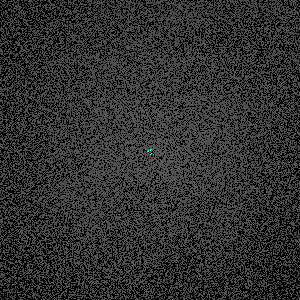

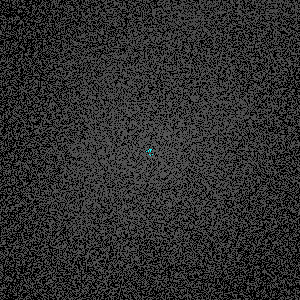

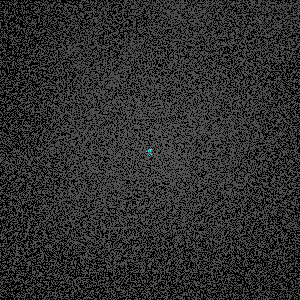

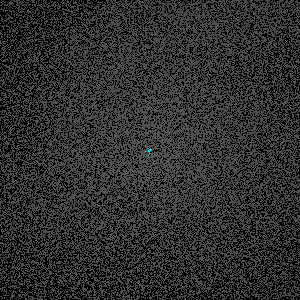

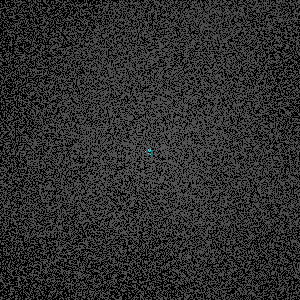

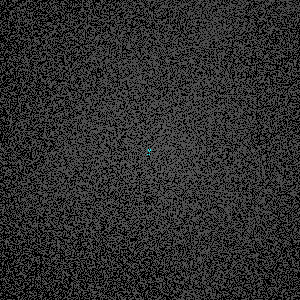

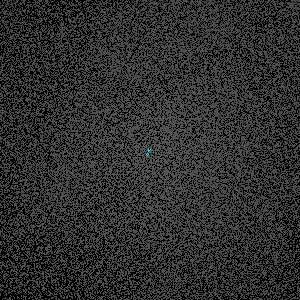

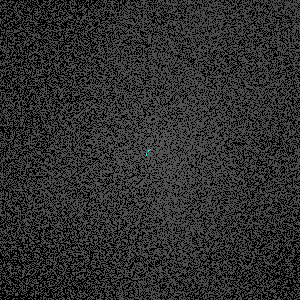

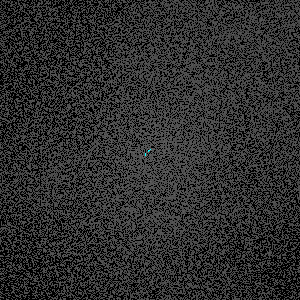


KeyboardInterrupt



<Figure size 300x300 with 0 Axes>

In [19]:
for (i, theta) in enumerate(np.linspace(0, 2*np.pi, 60)):
    fig, ax = plt.subplots(1,1, figsize=(100, 100), dpi=3, facecolor='black', constrained_layout=True)
    cos = np.cos(theta)
    sin = np.sin(theta)
    y = sin*gas_pos[:, X] + cos*gas_pos[:, Y] + y0
    plt.axis('off')
    plt.hist2d(
        x=(cos*gas_pos[:, X] - sin*gas_pos[:, Y])/y, 
        y=(gas_pos[:, Z])/y, 
        bins=(edges, edges), 
        weights=gas_mass.value,
        cmap='Greys_r',
        norm=LogNorm(vmin=1e35, vmax=1e48),
    )
    plt.hist2d(
        x=(cos*gas_pos[:, X] - sin*gas_pos[:, Y])/y, 
        y=(gas_pos[:, Z])/y, 
        bins=(edges, edges), 
        weights=gas_sfr,
        cmap=fade_cmaps[4],
        norm=LogNorm(vmin=1e-5, vmax=1e-1),
    )
    
    plt.savefig(f'{outpath}/sfr_zoom_{i:02}.png')
    plt.show()
    plt.clf()
    plt.close('all')

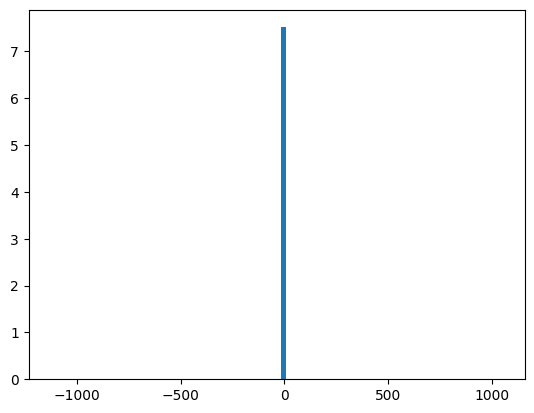

In [26]:
plt.hist(gas_pos[:, Z], weights=gas_sfr, bins=100)
plt.show()

0.037087385


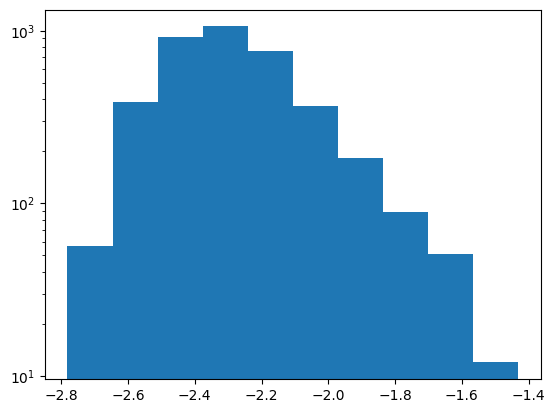

In [45]:
print(np.max(gas_sfr))
plt.hist(np.log10(gas_sfr[gas_sfr>1e-5]))
plt.gca().set_yscale('log')
plt.show()